# OOK Response Demodulator
We create a circuit to demodulate the signal from the card response

In [1]:
import math
import numpy as np
import sys
import pandas as pd
from scipy import signal

df = pd.read_csv('atqa_manresa_smart_container.csv', skiprows=4)
import matplotlib.pyplot as plt
import py4hw

In [2]:
from scipy.signal import kaiserord, lfilter, firwin, freqz
from scipy.signal import kaiserord, lfilter, firwin, freqz

# FIR filter
def highpass_filter(Fs, cutoff, db, ntaps, ripple_db):
    nyq_rate = Fs/2
    width = (0.1 * cutoff) 
    N, beta = kaiserord(db, width) #order/N:number of taps
    
    if (N > ntaps):
        print('WARNING: the kaiser window would require {} taps (more than the {} requested)'.format(N, ntaps))
    
    cutoff_hz = cutoff/nyq_rate #range of freq
    
    # Use firwin with a Kaiser window to create a lowpass FIR filter.
    taps = firwin(ntaps, cutoff_hz, window=('kaiser', beta), pass_zero='highpass')
    return taps



def lowpass_filter(Fs, cutoff, db, ntaps, ripple_db):
    nyq_rate = Fs/2
    width = (0.1 * cutoff) 
    N, beta = kaiserord(db, width) #order/N:number of taps
    
    if (N > ntaps):
        print('WARNING: the kaiser window would require {} taps (more than the {} requested)'.format(N, ntaps))
    
    cutoff_hz = cutoff/nyq_rate #range of freq
    
    # Use firwin with a Kaiser window to create a lowpass FIR filter.
    taps = firwin(ntaps, cutoff_hz, window=('kaiser', beta), pass_zero='lowpass')
    #taps = taps / np.sum(taps)
    
    return taps

class MultSignalByCoeff(py4hw.Logic):
    def __init__(self, parent, name, a, coeff, r):
        super().__init__(parent, name)
        
        self.addIn('a', a)
        self.addOut('r', r)
        
        w = a.getWidth()
        
        assert(w == r.getWidth())
        
        # inside signal
        sa = self.wire('sa', w) #The sign extension of a
        sr = self.wire('sr', 2*w) #multip result
        k = self.wire('k', w) #constant 2 w-1(index) 
        b = self.wire('b', w) 
        
        py4hw.Constant(self, 'k', 1<<(w-1), k) # w=16,k=1<<15=32768
        
        py4hw.Constant(self, 'coeff', int((1<<(w-1)) * coeff), b) #b = coeff × 2^(w−1)
        
        py4hw.SignedSub(self, 'sa', a, k, sa)
        py4hw.SignedMul(self, 'sr', sa, b, sr) #sr = sa(from a) × b(from coeff)
        
        py4hw.ShiftRightConstant(self, 'r', sr, w, r) #r = (a × coeff)
        
class highpassFilter(py4hw.Logic):
    def __init__(self, parent, name, Fs, cutoff, db, ntaps, x, r):
        super().__init__(parent, name)
        
        self.addIn('x', x)
        self.addOut('r', r)
        
        w = x.getWidth()
        z = [x]
        last = x
        
        # create the registers for z-1
        for i in range(ntaps-1):
            nwire = 'z_{}'.format(i+1)
            wire = self.wire(nwire, w)
            z.append(wire)
            py4hw.Reg(self, nwire, d=last, q=wire)
            last = wire
            
        taps = highpass_filter(Fs, cutoff, db, ntaps,db) #h[0], h[1], … h[N-1] FIR coeff
            
        for i in range(ntaps):
            pname = 'p{}'.format(i)
            p = self.wire(pname, w)
            
            MultSignalByCoeff(self, pname, z[i], taps[i], p) #p0 = z[0] × h[0]p0 = z[0] × h[0]... multi
            if (i == 0):
                last = p
            else:
                aname = 'a{}'.format(i)
                a = self.wire(aname, w)
                AddSignals(self, aname, p, last, a)
                last = a
                
        py4hw.Buf(self, 'buf', last, r) #r = Σ z[i] × h[i] plus       
        
        
class lowpassFilter(py4hw.Logic):
    def __init__(self, parent, name, Fs, cutoff, db, ntaps, x, r):
        super().__init__(parent, name)
        
        self.addIn('x', x)
        self.addOut('r', r)
        
        w = x.getWidth()
        z = [x]
        last = x
        
        # create the registers for z-1
        for i in range(ntaps-1):
            nwire = 'z_{}'.format(i+1)
            wire = self.wire(nwire, w)
            z.append(wire)
            py4hw.Reg(self, nwire, d=last, q=wire)
            last = wire
            
        taps = lowpass_filter(Fs, cutoff, db, ntaps,db) #h[0], h[1], … h[N-1] FIR coeff
            
        for i in range(ntaps):
            pname = 'p{}'.format(i)
            p = self.wire(pname, w)
            
            MultSignalByCoeff(self, pname, z[i], taps[i], p) #p0 = z[0] × h[0]p0 = z[0] × h[0]... multi
            if (i == 0):
                last = p
            else:
                aname = 'a{}'.format(i)
                a = self.wire(aname, w)
                AddSignals(self, aname, p, last, a)
                last = a
                
        py4hw.Buf(self, 'buf', last, r) #r = Σ z[i] × h[i] plus        
        
class AddSignals(py4hw.Logic):
    def __init__(self, parent, name, a, b, r):
        super().__init__(parent, name)
        
        self.addIn('a', a)
        self.addIn('b', b)
        self.addOut('r', r)
        
        sa = self.wire('sa', a.getWidth())
        sb = self.wire('sb', b.getWidth())
        sr = self.wire('sr', r.getWidth())
        k = self.wire('k', r.getWidth())
        
        py4hw.Constant(self, 'k', 1<<15, k)
        
        py4hw.SignedSub(self, 'sa', a, k, sa)
        py4hw.SignedSub(self, 'sb', b, k, sb)
        
        py4hw.Add(self, 'sr', sa, sb, sr)
        py4hw.Add(self, 'r', sr, k, r)        
        
        
#like SignalTap 
class StreamCapture(py4hw.Logic):
    def __init__(self, parent, name, x):
        super().__init__(parent, name)
        self.x = self.addIn('x', x)
        
        self.data = []
        
    def clock(self):
        self.data.append(self.x.get())

    def clear(self):
        self.data = []

class StreamCaptureSigned(py4hw.Logic):
    def __init__(self, parent, name, x):
        super().__init__(parent, name)
        self.x = self.addIn('x', x)
        
        self.data = []
        
    def clock(self):
        self.data.append(py4hw.IntegerHelper.c2_to_signed(self.x.get(), self.x.getWidth()))

    def clear(self):
        self.data = []          

In [3]:
raw_data = df[' uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data']

print(raw_data[1])
def conv(s):
    try:
        v = int(s,2)
    except:
        v = 0
    return v
    
def to_signed(v, w=16):
    if v >= (1 << (w-1)):
        return v - (1 << w)
    return v

iraw_data = [to_signed(conv(x), 16) for x in raw_data[1:]]
rx = np.array(iraw_data, dtype=np.int32)

 100101010011


In [14]:
class OOKDemodulator(py4hw.Logic):
    def __init__(self, parent, name , rx, ook):
        super().__init__(parent, name)
        
        Fs = 13.56e6
        Rb=106e3
        cutoff= Rb*9
        db = 60
        ntaps = 19
        
        self.addIn('rx', rx)
        self.addOut('ook', ook)
        
        #hp_w = hw.wire('hp_w', 16)
        x = self.wire('x', 16)
        abs_w = hw.wire('abs_w', 18)
        
        hp = highpassFilter(self, 'high_pass', Fs, cutoff, db, ntaps, rx, x)
        abs1 = py4hw.Abs(self, 'abs', x, abs_w)

        cutoff=106e3*0.5
        
        lp_w = self.wire('lp_w', 18)
        lp = lowpassFilter(self,'low_pass', Fs, cutoff, db, ntaps, abs_w, lp_w)

        bit_w = self.wire('bit_w',1)
        thr_const_w = self.wire('thr_const_w', 18)

        TH_VAL =42.74
        py4hw.Constant(self,'thr_const', int(TH_VAL), thr_const_w)

        #gt = self.wire('gt')
        gt = ook
        eq = self.wire('eq')
        lt = self.wire('lt')

        py4hw.Comparator(self, 'cmp_thr', lp_w, thr_const_w, gt, eq, lt)


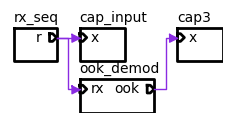

In [15]:
hw = py4hw.HWSystem()
hlp = py4hw.LogicHelper(hw)



# INPUT = rw_w
rx_w = hw.wire('rx_w', 16)
ook = hw.wire('ook')


rx_int = [int(x) for x in rx]
py4hw.Sequence(hw, 'rx_seq', rx_int, rx_w)

cap_input = StreamCapture(hw, 'cap_input', rx_w) 

dut = OOKDemodulator(hw, 'ook_demod', rx_w, ook)

cap3 = StreamCapture(hw, 'cap3', ook)

sch = py4hw.Schematic(hw)
sch.drawAll()
#plt.savefig('topFIR.png')

In [16]:
hw.getSimulator().clk(2000)
cap_input.clear()
cap3.clear()
hw.getSimulator().clk(5000-2000)

#print(rx_w.get())
#rx[:10].astype(int)

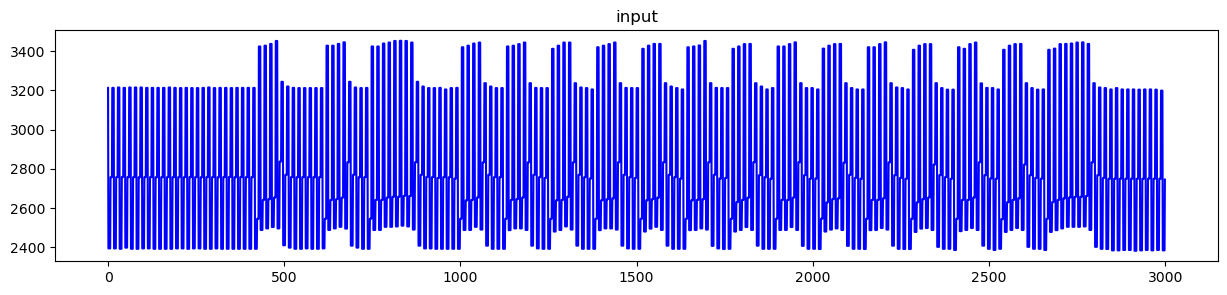

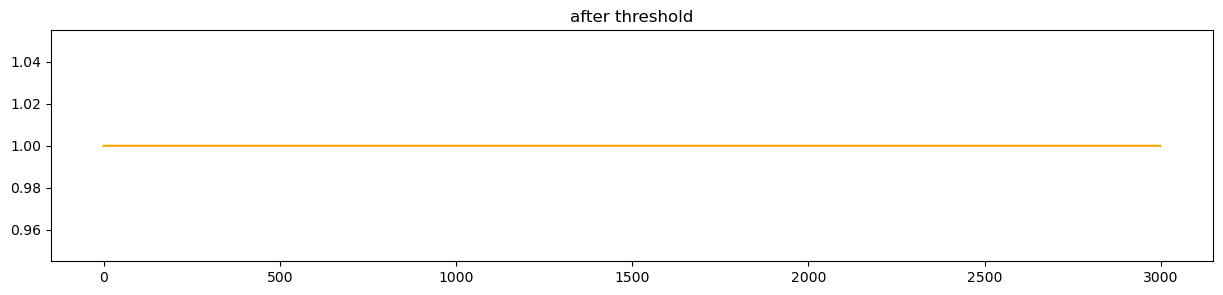

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,3))
plt.plot(cap_input.data, color='blue')
#plt.savefig('filteredsignal.png')
plt.title('input')
plt.show()


plt.figure(figsize=(15,3))
plt.plot(cap3.data, color='orange')
plt.title('after threshold')
#plt.savefig('filteredsignal.png')
plt.show()

In [8]:
py4hw.gui.Workbench(hw)

('#all',)
SystemWindow
Circuit detail on  None


In [9]:
rtl = py4hw.VerilogGenerator(dut)

print(rtl.getVerilogForHierarchy(dut))

// This file was automatically created by py4hw Verilog generator
module OOKDemodulator (
	input clk,
	input [15:0] rx,
	output  ook);
wire [17:0] w_lp_w;
wire [15:0] w_x;
wire w_eq;
wire [17:0] w_abs_w;
wire w_lt;
wire [17:0] w_thr_const_w;

highpassFilter_20f4fc30cd0 i_high_pass(.clk(clk),.x(rx),.r(w_x));
Abs16_18 i_abs(.a(w_x),.r(w_abs_w));
lowpassFilter_20f4fdaa990 i_low_pass(.clk(clk),.x(w_abs_w),.r(w_lp_w));
assign w_thr_const_w[17:0] = 42;
Comparator_20f4fe2d390 i_cmp_thr(.a(w_lp_w),.b(w_thr_const_w),.gt(ook),.eq(w_eq),.lt(w_lt));
endmodule

// This file was automatically created by py4hw Verilog generator
module highpassFilter_20f4fc30cd0 (
	input clk,
	input [15:0] x,
	output [15:0] r);
wire [15:0] w_z_3;
wire [15:0] w_z_7;
wire [15:0] w_a12;
wire [15:0] w_a10;
wire [15:0] w_z_10;
wire [15:0] w_p0;
wire [15:0] w_a8;
wire [15:0] w_z_1;
wire [15:0] w_a1;
wire [15:0] w_a6;
wire [15:0] w_a4;
wire [15:0] w_p14;
wire [15:0] w_a2;
wire [15:0] w_p5;
wire [15:0] w_p12;
wire [15:0] w_z_